# `nanonet` Tutorial

This notebook walks through the full workflow of the `nanonet` package:

1. **Network creation** — set `L`, `N`, `fv`, `mu_a`, `std_a`
2. **I-V curve** — Kirchhoff nodal analysis
3. **Microscopic analysis** — node potentials, edge currents, resistance
4. **Full sweep** — activation, connectivity, current distribution, spectral metrics
5. **Parameter sweeps** — varying `std_a`, `mu_a`, `N`, and `fv`
6. **Visualization** — all built-in plot functions

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import nanonet
from nanonet import (
    NanoparticleNetwork,
    sweep,
    write_iv_csv, write_csv, write_edge_currents_csv,
    effective_resistance, spectral_metrics,
    plot_iv_curve, plot_evolution, plot_snapshots,
    plot_spectral_evolution,
)
from nanonet.sweeps import (
    SweepConfig,
    run_sweep_vary_mean,
    run_sweep_vary_std,
    run_sweep_vary_N,
    run_sweep_vary_voids,
)
from nanonet.sweeps.parameter_sweep import make_fit_table, aggregate_fit_table

# ── output directory ──────────────────────────────────────────────
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)
print(f"All outputs will be saved to: {RESULTS.resolve()}/")

# ── global plot style ─────────────────────────────────────────────
FONT = 20        # axis labels / titles
TICK = 15        # tick labels
LEGEND = 16      # legend text
plt.rcParams.update({
    "font.size":        FONT,
    "axes.titlesize":   FONT,
    "axes.labelsize":   FONT,
    "xtick.labelsize":  TICK,
    "ytick.labelsize":  TICK,
    "legend.fontsize":  LEGEND,
})

print("nanonet version:", nanonet.__version__)

All outputs will be saved to: /Users/hoon/graph-based-nanoparticle-necklace-network/results/
nanonet version: 0.1.0


---
## 1. Create a Network

The five main parameters:

| Parameter | Meaning |
|-----------|---------|
| `L` | Domain size (normalised units). Float → square; tuple → (width, height). |
| `N` | Number of junction nodes requested. |
| `fv` | Void-area fraction `[0, 1)`. `0` = dense film. |
| `mu_a` | Mean of the activation-voltage distribution `[V]`. |
| `std_a` | Standard deviation of the activation-voltage distribution `[V]`. |

All other parameters (edge resistance constant, electrode thresholds, …) are keyword-only with sensible defaults.

In [2]:
# --- main parameters ---
L     = 1.0    # domain size: 1 × 1
N     = 300    # number of junctions
fv    = 0.0    # void fraction (0 = no voids)
mu_a  = 6.0    # mean activation voltage [V]
std_a = 3.0    # std of activation voltage [V]

net = NanoparticleNetwork(
    L=L, N=N, fv=fv,
    mu_a=mu_a, std_a=std_a,
    source_frac=0.15,   # left 15% of domain → source electrodes  (default)
    drain_frac=0.15,    # right 15% of domain → drain electrodes   (default)
).build(seed=42)


print(net.network_summary())

Network: 300 nodes, 2830 edges
Electrodes: 61 sources (x ≤ 0.150), 37 drains (x ≥ 0.850)
{'n_nodes': 300, 'n_edges': 2830, 'n_sources': 61, 'n_drains': 37, 'mean_degree': 18.866666666666667, 'density': 0.06309921962095875, 'is_connected': True, 'mu_a_actual': 5.964268048559629, 'std_a_actual': 2.819633507705121}


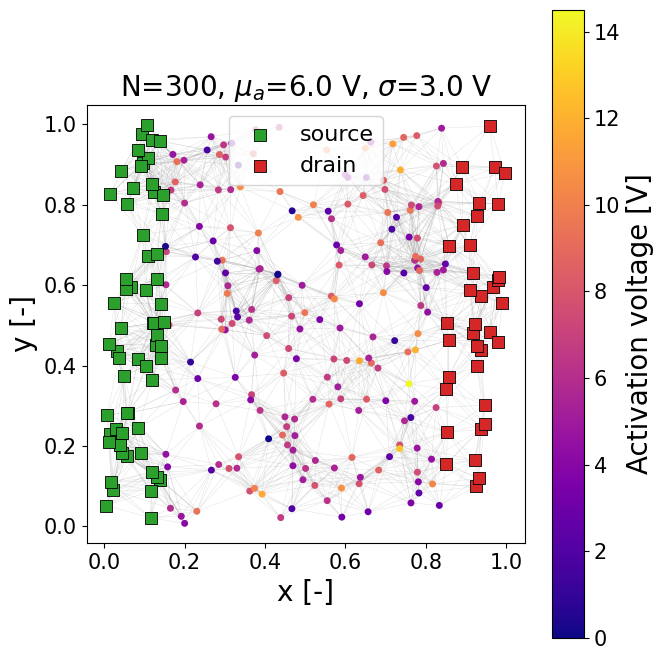

Saved results/topology.png


In [3]:
# Visualise the network topology: nodes coloured by activation voltage
pos = net.positions
node_ids = list(net.G.nodes())
vth_vals = [net.G.nodes[n]["Vth"] for n in node_ids]

fig, ax = plt.subplots(figsize=(7, 7))

# edges
for i, j in net.G.edges():
    ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
            lw=0.4, alpha=0.2, color="0.5")

# nodes coloured by Vth
sc = ax.scatter(pos[node_ids, 0], pos[node_ids, 1],
                c=vth_vals, cmap="plasma", s=25, edgecolors="none", zorder=3)
cbar = plt.colorbar(sc, ax=ax) 
cbar.set_label("Activation voltage [V]", fontsize=FONT)
cbar.ax.tick_params(labelsize=TICK)

# electrodes
if net.source_nodes:
    s = np.array(net.source_nodes)
    ax.scatter(pos[s, 0], pos[s, 1], marker="s", s=80,
               c="tab:green", edgecolors="k", lw=0.6, zorder=4, label="source")
if net.drain_nodes:
    d = np.array(net.drain_nodes)
    ax.scatter(pos[d, 0], pos[d, 1], marker="s", s=80,
               c="tab:red", edgecolors="k", lw=0.6, zorder=4, label="drain")

ax.set_aspect("equal")
ax.legend()
ax.set_title(f"N={net.n_junctions}, $\\mu_a$={mu_a} V, $\\sigma$={std_a} V")
ax.set_xlabel("x [-]")
ax.set_ylabel("y [-]")
plt.tight_layout()
plt.savefig(RESULTS / "topology.png", dpi=150)
plt.show()
print(f"Saved {RESULTS}/topology.png")

---
## 2. I-V Curve

`net.iv_curve()` sweeps the applied voltage and solves Kirchhoff nodal analysis at each step.  
Nodes with `Vₐ ≤ V_applied` activate; the live sub-network is solved exactly.

Threshold voltage   : 4.0 V
Peak current        : 59.446 nA
Max conductance     : 3715.404 pS


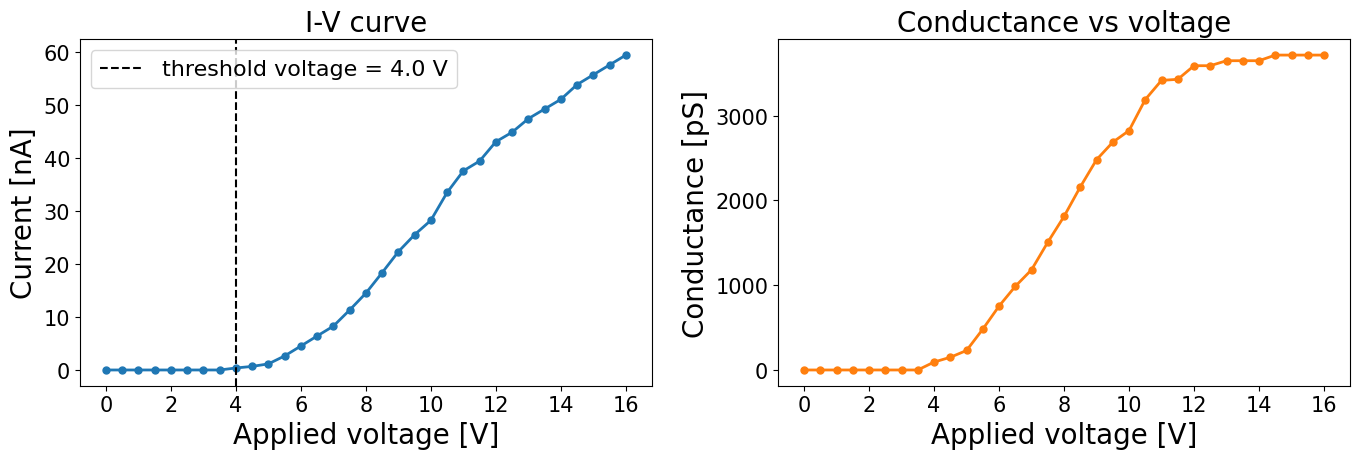

In [4]:
iv = net.iv_curve(V_start=0.0, V_max=16.0, V_step=0.5)

print(f"Threshold voltage   : {iv['threshold_voltage']} V")
print(f"Peak current        : {iv['currents'].max()*1e9:.3f} nA")
print(f"Max conductance     : {iv['conductances'].max()*1e12:.3f} pS")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(iv["voltages"], iv["currents"] * 1e9, "-o", ms=5, lw=2, color="tab:blue")
if iv["threshold_voltage"] is not None:
    ax.axvline(iv["threshold_voltage"], color="k", ls="--", lw=1.5,
               label=f"threshold voltage = {iv['threshold_voltage']} V")
    ax.legend()
ax.set_xlabel("Applied voltage [V]")
ax.set_ylabel("Current [nA]")
ax.set_title("I-V curve")

ax = axes[1]
ax.plot(iv["voltages"], iv["conductances"] * 1e12, "-o", ms=5, lw=2, color="tab:orange")
ax.set_xlabel("Applied voltage [V]")
ax.set_ylabel("Conductance [pS]")
ax.set_title("Conductance vs voltage")

plt.tight_layout()
plt.savefig(RESULTS / "iv_curve.png", dpi=150)
plt.show()

---
## 3. Microscopic Analysis at a Single Voltage

`net.edge_currents(V_applied)` returns:
- `total_current` — net current from source to drain [A]
- `node_potentials` — solved potential at every conducting node [V]
- `edge_currents` — signed current on every conducting edge [A] (positive = flow i→j)
- `overall_resistance` — effective source-to-drain resistance [Ω]

In [5]:
V_probe = 10.0   # voltage to analyse [V]

mic = net.edge_currents(V_applied=V_probe)

print(f"=== Microscopic analysis at V = {V_probe} V ===")
print(f"  Total current        : {mic['total_current']*1e9:.4f} nA")
print(f"  Activated nodes      : {len(mic['activated_nodes'])}")
print(f"  Conducting edges     : {mic['conducting_edges']}")
print(f"  Overall resistance   : {net.overall_resistance(V_probe):.3e} Ω")

# Node potentials (first 10)
phi = mic["node_potentials"]
print(f"\n  Node potentials (first 10 nodes):")
for node, V_node in sorted(phi.items())[:10]:
    print(f"    node {node:4d}: {V_node:.4f} V")

# Edge current statistics
edge_currents_vals = np.array(list(mic["edge_currents"].values()))
if len(edge_currents_vals):
    abs_I = np.abs(edge_currents_vals)
    print(f"\n  Edge current statistics:")
    print(f"    max  |I| : {abs_I.max()*1e9:.4f} nA")
    print(f"    mean |I| : {abs_I.mean()*1e9:.4f} nA")
    print(f"    Gini coef: {( 2*np.sum(np.arange(1,len(abs_I)+1)*np.sort(abs_I)) - (len(abs_I)+1)*abs_I.sum() ) / (len(abs_I)*abs_I.sum()):.3f}")

=== Microscopic analysis at V = 10.0 V ===
  Total current        : 28.2437 nA
  Activated nodes      : 275
  Conducting edges     : 1856
  Overall resistance   : 3.541e+08 Ω

  Node potentials (first 10 nodes):
    node    1: 0.0000 V
    node    2: 10.0000 V
    node    3: 0.4733 V
    node    4: 10.0000 V
    node    5: 9.5206 V
    node    6: 1.0797 V
    node    7: 5.4018 V
    node    8: 4.2025 V
    node    9: 0.3360 V
    node   11: 0.0000 V

  Edge current statistics:
    max  |I| : 1.5675 nA
    mean |I| : 0.2107 nA
    Gini coef: 0.494


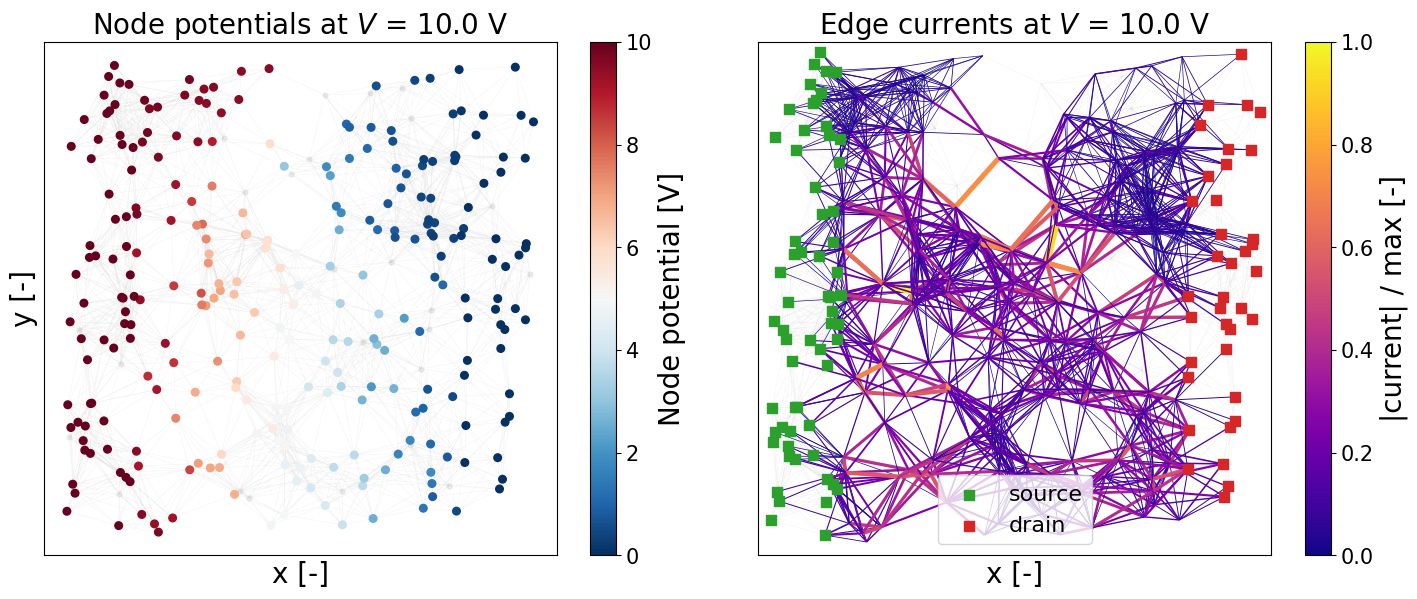

In [6]:
# Visualise node potentials and edge currents at V_probe
from matplotlib.collections import LineCollection

pos = net.positions
ec  = mic["edge_currents"]
phi = mic["node_potentials"]

abs_vals = np.array([abs(c) for c in ec.values()]) if ec else np.array([1.0])
I_max = abs_vals.max() or 1.0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- left panel: node potentials ---
ax = axes[0]
segs_all = [[(pos[i][0], pos[i][1]), (pos[j][0], pos[j][1])] for i, j in net.G.edges()]
ax.add_collection(LineCollection(segs_all, colors="lightgray", linewidths=0.3, alpha=0.3))

conducting = sorted(phi.keys())
inactive   = [n for n in net.G.nodes() if n not in phi]
if inactive:
    ax.scatter(pos[inactive, 0], pos[inactive, 1], s=12, c="lightgray", alpha=0.4)
if conducting:
    potentials = [phi[n] for n in conducting]
    sc = ax.scatter(pos[conducting, 0], pos[conducting, 1],
                    c=potentials, cmap="RdBu_r", s=30, vmin=0, vmax=V_probe, zorder=3)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Node potential [V]", fontsize=FONT)
    cbar.ax.tick_params(labelsize=TICK)
ax.set_aspect("equal")
ax.set_title(f"Node potentials at $V$ = {V_probe} V")
ax.set_xlabel("x [-]"); ax.set_ylabel("y [-]")
ax.set_xticks([]); ax.set_yticks([])

# --- right panel: edge currents ---
ax = axes[1]
ax.add_collection(LineCollection(segs_all, colors="lightgray", linewidths=0.3, alpha=0.3))

if ec:
    segs, widths, cvals = [], [], []
    for (i, j), c in ec.items():
        segs.append([(pos[i][0], pos[i][1]), (pos[j][0], pos[j][1])])
        mag = abs(c)
        widths.append(0.4 + 4.5 * mag / I_max)
        cvals.append(mag / I_max)
    lc = LineCollection(segs, array=np.array(cvals), cmap="plasma",
                        linewidths=widths, zorder=3)
    lc.set_clim(0, 1)
    ax.add_collection(lc)
    sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("|current| / max [-]", fontsize=FONT)
    cbar.ax.tick_params(labelsize=TICK)

if net.source_nodes:
    s = np.array(net.source_nodes)
    ax.scatter(pos[s,0], pos[s,1], s=50, marker="s", c="tab:green", zorder=5, label="source")
if net.drain_nodes:
    d = np.array(net.drain_nodes)
    ax.scatter(pos[d,0], pos[d,1], s=50, marker="s", c="tab:red", zorder=5, label="drain")
ax.legend()
ax.set_aspect("equal")
ax.set_title(f"Edge currents at $V$ = {V_probe} V")
ax.set_xlabel("x [-]")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(RESULTS / "microscopic.png", dpi=150)
plt.show()

---
## 4. Full Voltage Sweep

`sweep()` runs the complete per-voltage analysis:

| Column | Meaning |
|--------|---------|
| `activated_nodes/edges` | How many nodes/edges have `Vₐ ≤ V` |
| `conducting_edges` | Edges actually carrying current (on a source→drain path) |
| `source_drain_connected` | 1 after percolation |
| `total_current_A` | Kirchhoff solver current |
| `current_gini` | Gini coefficient of edge-current distribution (0=uniform, 1=single edge) |
| `largest_cc_fraction` | Percolation order parameter |
| `effective_resistance_ohm` | Source-to-drain resistance from the full Laplacian |
| `algebraic_connectivity` | Fiedler value (network robustness) |

> **Tip:** set `algebraic_connectivity=False` for faster sweeps on large networks.

In [7]:
result = sweep(
    net,
    V_start=0.0, V_max=16.0, V_step=0.5,
    effective_resistance=True,
    algebraic_connectivity=True,   # set False to skip (expensive for large N)
)

print(f"Percolation voltage : {result['percolation_V']} V")
print(f"Total nodes         : {result['n_total_nodes']}")
print(f"Total edges         : {result['n_total_edges']}")
print(f"\nColumns available   : {result['fieldnames']}")

Percolation voltage : 4.0 V
Total nodes         : 300
Total edges         : 2830

Columns available   : ['V', 'activated_nodes', 'activated_edges', 'conducting_nodes', 'conducting_edges', 'source_drain_connected', 'total_current_A', 'total_current_chargeconserving_A', 'conductance_S', 'backbone_edges', 'participation_ratio', 'num_components', 'largest_cc_nodes', 'second_cc_nodes', 'largest_cc_fraction', 'mean_finite_cc', 'current_cv', 'current_gini', 'current_max_to_mean', 'current_top10_fraction', 'effective_resistance_ohm', 'algebraic_connectivity', 'spectral_gap_ratio']


In [8]:
# Export the sweep results to CSV
write_iv_csv(result, RESULTS / "iv.csv")
write_csv(result, RESULTS / "full_sweep.csv")
write_edge_currents_csv(net, result, RESULTS / "edge_currents.csv",
                        voltages=[4.0, 8.0, 12.0, 16.0])
print(f"CSVs written to {RESULTS}/")

# Preview
import pandas as pd
df = pd.read_csv(RESULTS / "full_sweep.csv")
df[["V","activated_nodes","conducting_edges","total_current_A","current_gini",
    "largest_cc_fraction","effective_resistance_ohm","algebraic_connectivity"]].tail(8)

CSVs written to results/


,V,activated_nodes,conducting_edges,total_current_A,current_gini,largest_cc_fraction,effective_resistance_ohm,algebraic_connectivity
25,12.5,297,2137,4.487565e-08,0.461710,1.0,2.785475e+08,5.435689e-11
26,13.0,299,2165,4.743711e-08,0.462870,1.0,2.740471e+08,5.444828e-11
27,13.5,299,2165,4.926161e-08,0.462870,1.0,2.740471e+08,5.444828e-11
28,14.0,299,2165,5.108612e-08,0.462870,1.0,2.740471e+08,5.444828e-11
29,14.5,300,2184,5.387335e-08,0.463443,1.0,2.691498e+08,5.474117e-11
30,15.0,300,2184,5.573106e-08,0.463443,1.0,2.691498e+08,5.474117e-11
31,15.5,300,2184,5.758876e-08,0.463443,1.0,2.691498e+08,5.474117e-11
32,16.0,300,2184,5.944646e-08,0.463443,1.0,2.691498e+08,5.474117e-11


All figures saved to results/


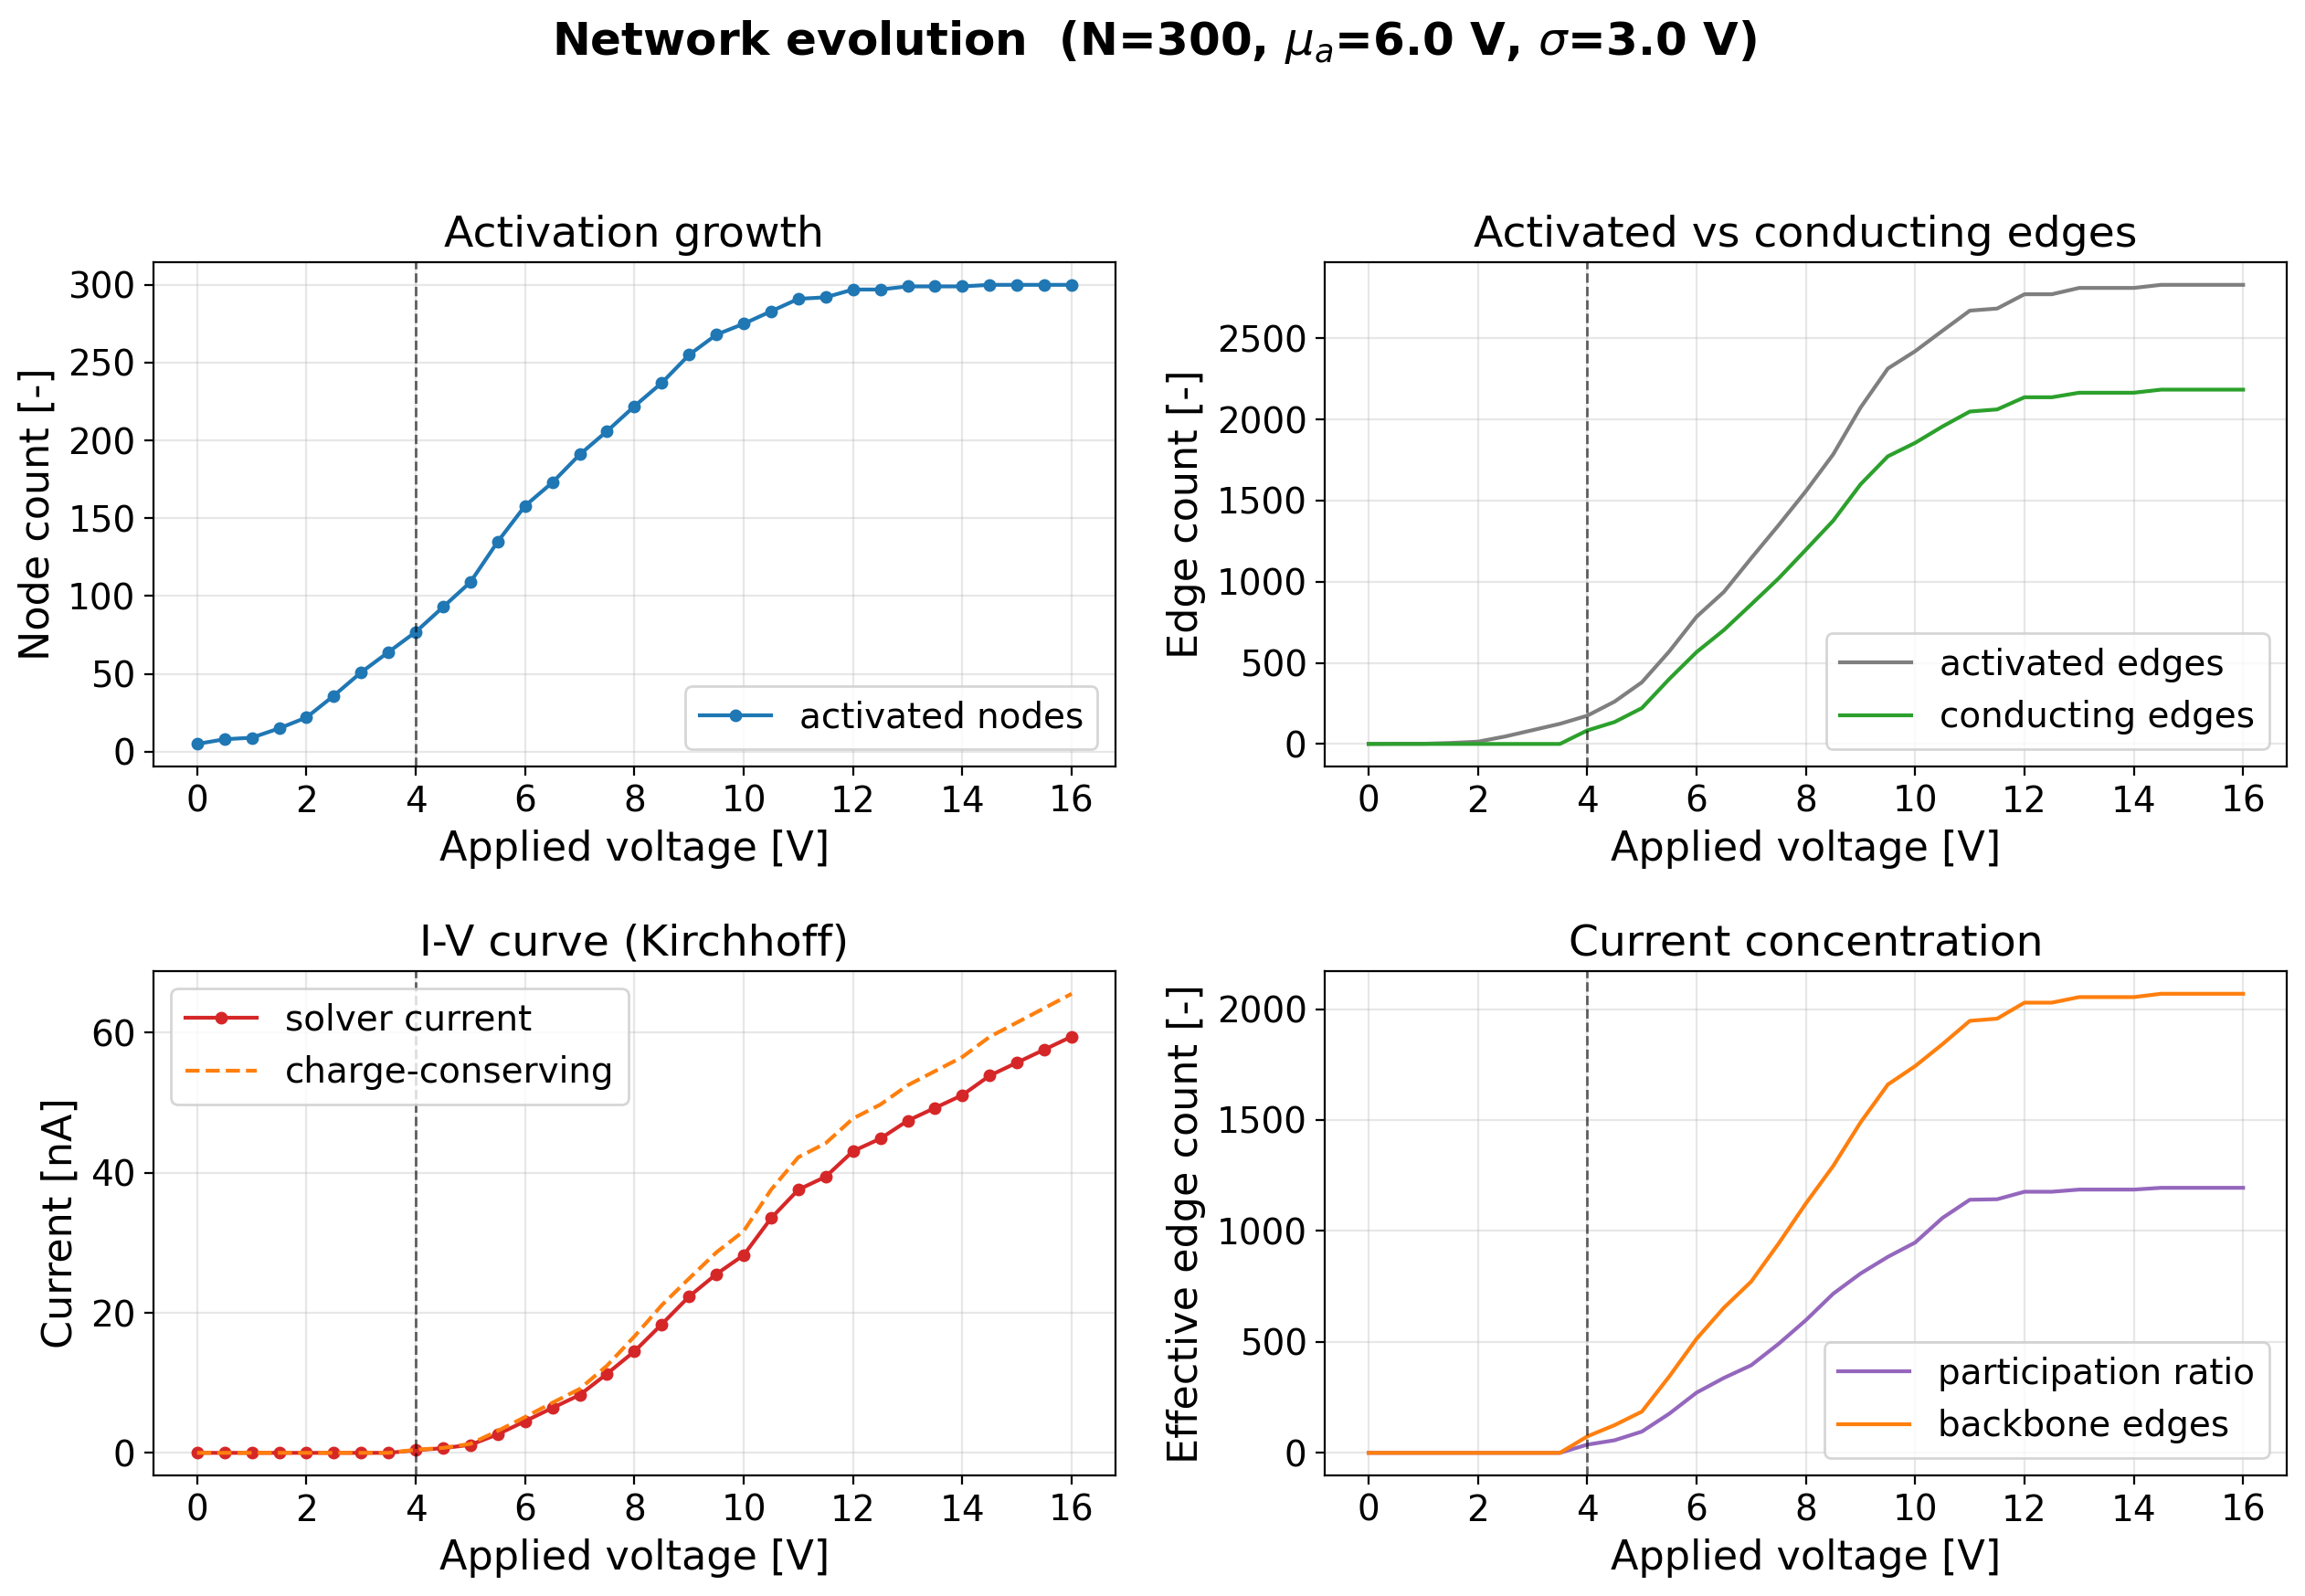

In [9]:
# --- Built-in sweep figures ---

# 4-panel evolution plot
plot_evolution(result["rows"], result["fieldnames"],
               title=f"Network evolution  (N={net.n_junctions}, $\\mu_a$={mu_a} V, $\\sigma$={std_a} V)",
               outpath=str(RESULTS / "evolution.png"),
               percolation_V=result["percolation_V"])

# Spectral panel
plot_spectral_evolution(result["rows"], result["fieldnames"],
                        title="Spectral metrics",
                        outpath=str(RESULTS / "spectral.png"))

# Network snapshots (conduction spreading)
plot_snapshots(net, snap_voltages=[4.0, 8.0, 12.0, 16.0],
               outpath=str(RESULTS / "snapshots.png"))

print(f"All figures saved to {RESULTS}/")

# Display inline
from IPython.display import Image
Image(str(RESULTS / "evolution.png"))

---
## 5. Spectral Metrics at a Single Voltage

`effective_resistance` and `spectral_metrics` can also be called directly (they are used internally by `sweep`).

In [10]:
V_probe = 12.0
activated = {n for n in net.G.nodes() if net.G.nodes[n]["Vth"] <= V_probe}

R_eff = effective_resistance(net, activated)
alg_conn, gap_ratio, n_zero = spectral_metrics(net, activated)

print(f"At V = {V_probe} V  ({len(activated)} activated nodes):")
print(f"  Effective resistance     : {R_eff:.4e} Ω")
print(f"  Algebraic connectivity   : {alg_conn:.4e}  (Fiedler value)")
print(f"  Spectral gap ratio       : {gap_ratio:.4e}  (λ₂/λ_max)")
print(f"  Near-zero eigenvalues    : {n_zero}  (disconnected components in Laplacian)")

At V = 12.0 V  (297 activated nodes):
  Effective resistance     : 2.7855e+08 Ω
  Algebraic connectivity   : 5.4357e-11  (Fiedler value)
  Spectral gap ratio       : 6.7926e-04  (λ₂/λ_max)
  Near-zero eigenvalues    : 1  (disconnected components in Laplacian)


---
## 6. Parameter Sweeps

`SweepConfig` holds the full parameter grid. Each sweep function varies one parameter while holding the rest fixed:

| Order | Function | Varied | Fixed |
|-------|----------|--------|-------|
| 6a | `run_sweep_vary_mean` | `mu_a` | each σ in `sigma_values_mean`, `N` |
| 6b | `run_sweep_vary_std` | `std_a` (σ) | `mu_a`, `N` |
| 6c | `run_sweep_vary_N` | `N` | `mu_a`, `std_a` |
| 6d | `run_sweep_vary_voids` | `fv` (void fraction) | `N`, `mu_a`, `std_a` |

Each function returns a **list of result dicts**, one per `(parameters, seed)` combo.  
`make_fit_table()` summarises the power-law fit `I = A(V − V_T)^ζ`.  
Each plot shows **I-V overlay**, **V_T vs parameter**, and **ζ vs parameter**.

### 6a. `run_sweep_vary_mean` — Vary μₐ (mean activation voltage)

In [11]:
cfg_mean = SweepConfig(
    L=1.0,
    N=200,
    V_start=0.0, V_max=16.0, V_step=1.0,
    seeds=[42, 51],
    max_workers=2,
    # vary_mean grid: sweep mu_a at a single fixed sigma
    mean_values=[3.0, 5.0, 7.0, 9.0],
    sigma_values_mean=[3.0],   # one sigma value → one group
    fixed_mean=6.0,            # unused by vary_mean, kept for completeness
)

vary_mean_results_by_sigma = run_sweep_vary_mean(cfg_mean)
# dict keyed by sigma; grab the only group
vary_mean_results = vary_mean_results_by_sigma[3.0]
print(f"run_sweep_vary_mean: {len(vary_mean_results)} runs completed")

fit_table_mean = make_fit_table(vary_mean_results, "vary_mean")
print(fit_table_mean[["mean_Va_target_V","seed","percolation_voltage_V","fit_V_T_V","fit_zeta","fit_R2"]].to_string(index=False))

Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
run_sweep_vary_mean: 8 runs completed
 mean_Va_target_V  seed  percolation_voltage_V  fit_V_T_V  fit_zeta   fit_R2
              3.0    42                    1.0   0.000000  2.543875 0.989752
              3.0    51                    2.0   1.743589  1.499143 0.998804
              5.0  

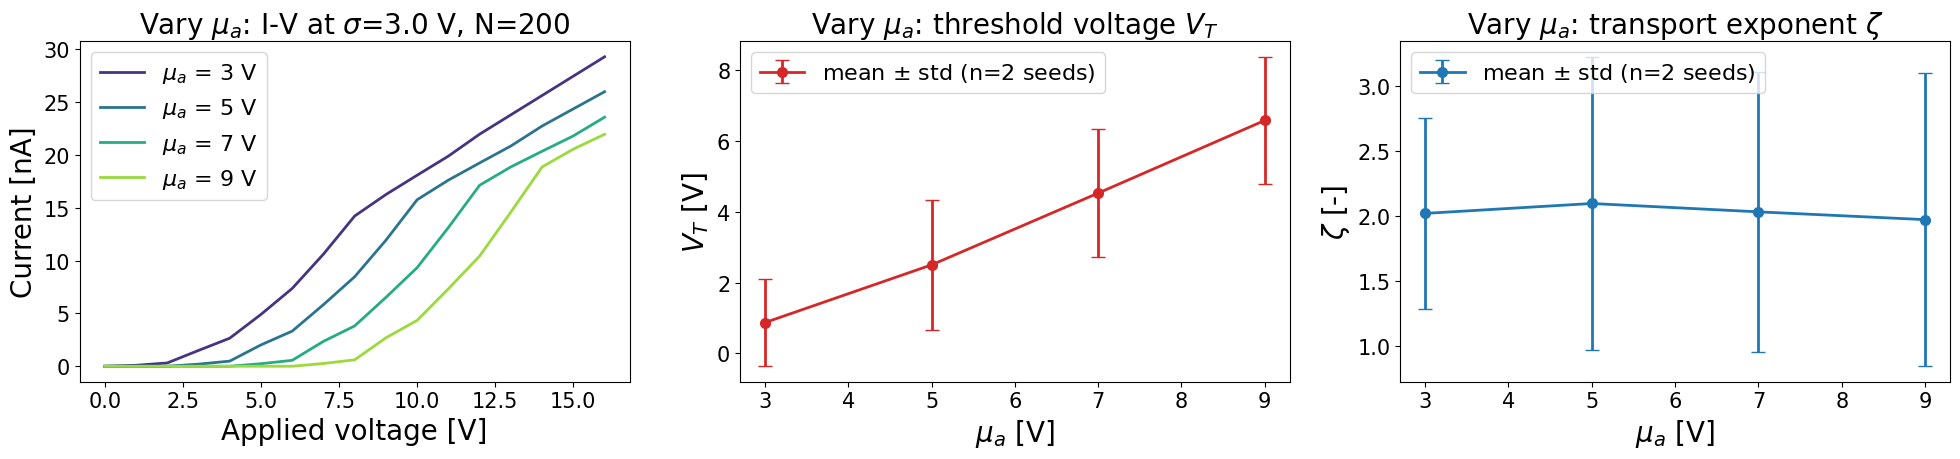

In [12]:
# Plot I-V overlay, V_T and ζ vs μₐ

rep_by_mean = {}
for r in vary_mean_results:
    m = r["mean_va_target"]
    if m not in rep_by_mean or r["seed"] < rep_by_mean[m]["seed"]:
        rep_by_mean[m] = r
reps_mean = [rep_by_mean[m] for m in sorted(rep_by_mean)]

agg_mean = aggregate_fit_table(vary_mean_results, "mean_va_target", "mean_Va_target_V")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(reps_mean)))

ax = axes[0]
for c, r in zip(colors, reps_mean):
    ax.plot(r["voltages"], np.asarray(r["currents"]) * 1e9, lw=2, color=c,
            label=f"$\\mu_a$ = {r['mean_va_target']:.0f} V")
ax.set_xlabel("Applied voltage [V]")
ax.set_ylabel("Current [nA]")
ax.set_title(f"Vary $\\mu_a$: I-V at $\\sigma$={cfg_mean.sigma_values_mean[0]} V, N={cfg_mean.N}")
ax.legend()

ax = axes[1]
ax.errorbar(agg_mean["mean_Va_target_V"], agg_mean["VT_mean"], yerr=agg_mean["VT_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:red",
            label=f"mean $\\pm$ std (n={len(cfg_mean.seeds)} seeds)")
ax.set_xlabel("$\\mu_a$ [V]")
ax.set_ylabel("$V_T$ [V]")
ax.set_title("Vary $\\mu_a$: threshold voltage $V_T$")
ax.legend()

ax = axes[2]
ax.errorbar(agg_mean["mean_Va_target_V"], agg_mean["zeta_mean"], yerr=agg_mean["zeta_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:blue",
            label=f"mean $\\pm$ std (n={len(cfg_mean.seeds)} seeds)")
ax.set_xlabel("$\\mu_a$ [V]")
ax.set_ylabel("$\\zeta$ [-]")
ax.set_title("Vary $\\mu_a$: transport exponent $\\zeta$")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "vary_mean.png", dpi=150)
plt.show()

### 6b. `run_sweep_vary_std` — Vary σ (activation-voltage width)

Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1206 edges
Electrodes: 34 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1206 edges
Electrodes: 34 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1206 edges
Electrodes: 34 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1

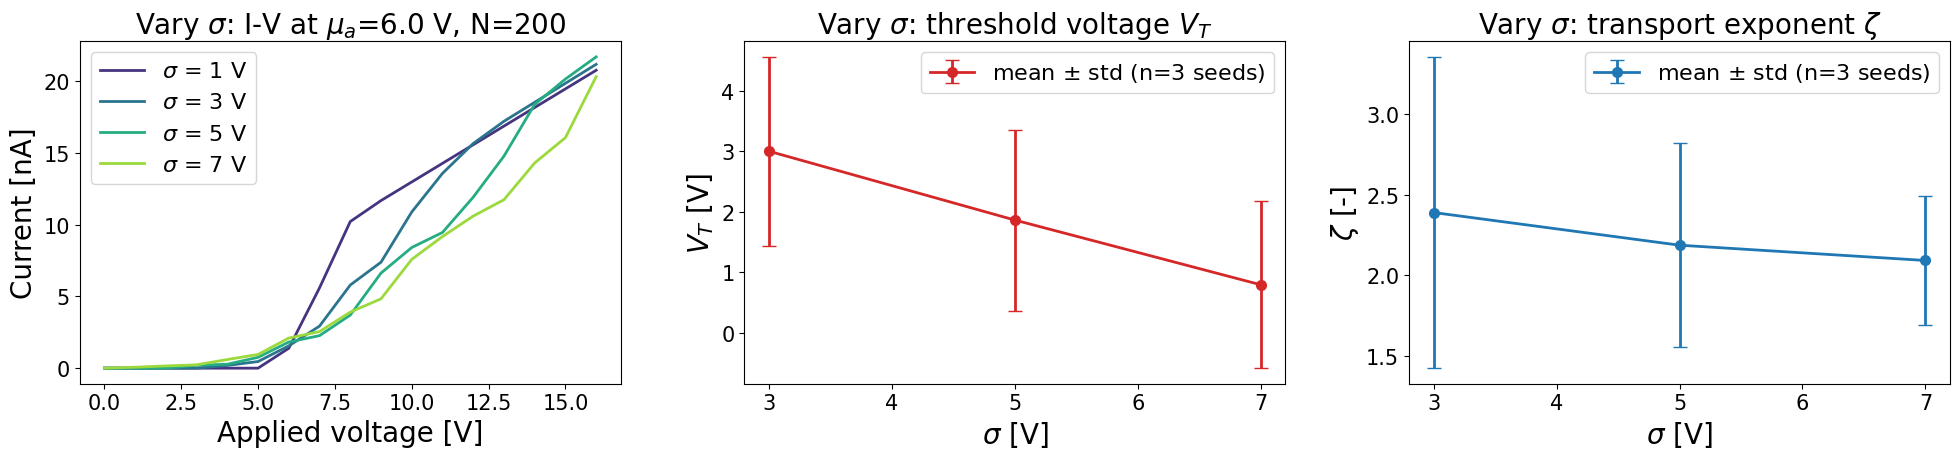

In [13]:
cfg_std = SweepConfig(
    L=1.0,
    N=200,
    mu_a=6.0,
    V_start=0.0, V_max=16.0, V_step=1.0,
    seeds=[42, 51, 27],
    max_workers=2,
    sigma_values=[1.0, 3.0, 5.0, 7.0],
    fixed_mean=6.0,
)

vary_std_results = run_sweep_vary_std(cfg_std)
print(f"run_sweep_vary_std: {len(vary_std_results)} runs completed")

rep_by_sigma = {}
for r in vary_std_results:
    s = r["sigma_va_target"]
    if s not in rep_by_sigma or r["seed"] < rep_by_sigma[s]["seed"]:
        rep_by_sigma[s] = r
reps_std = [rep_by_sigma[s] for s in sorted(rep_by_sigma)]

agg_std = aggregate_fit_table(vary_std_results, "sigma_va_target", "sigma_Va_target_V")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(reps_std)))

ax = axes[0]
for c, r in zip(colors, reps_std):
    ax.plot(r["voltages"], np.asarray(r["currents"]) * 1e9, lw=2, color=c,
            label=f"$\\sigma$ = {r['sigma_va_target']:.0f} V")
ax.set_xlabel("Applied voltage [V]")
ax.set_ylabel("Current [nA]")
ax.set_title(f"Vary $\\sigma$: I-V at $\\mu_a$={cfg_std.fixed_mean} V, N={cfg_std.N}")
ax.legend()

ax = axes[1]
ax.errorbar(agg_std["sigma_Va_target_V"], agg_std["VT_mean"], yerr=agg_std["VT_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:red",
            label=f"mean $\\pm$ std (n={len(cfg_std.seeds)} seeds)")
ax.set_xlabel("$\\sigma$ [V]")
ax.set_ylabel("$V_T$ [V]")
ax.set_title("Vary $\\sigma$: threshold voltage $V_T$")
ax.legend()

ax = axes[2]
ax.errorbar(agg_std["sigma_Va_target_V"], agg_std["zeta_mean"], yerr=agg_std["zeta_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:blue",
            label=f"mean $\\pm$ std (n={len(cfg_std.seeds)} seeds)")
ax.set_xlabel("$\\sigma$ [V]")
ax.set_ylabel("$\\zeta$ [-]")
ax.set_title("Vary $\\sigma$: transport exponent $\\zeta$")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "vary_std.png", dpi=150)
plt.show()

### 6c. `run_sweep_vary_N` — Vary N (junction count)

Network: 100 nodes, 324 edges
Electrodes: 15 sources (x ≤ 0.150), 19 drains (x ≥ 0.850)
Network: 100 nodes, 347 edges
Electrodes: 16 sources (x ≤ 0.150), 8 drains (x ≥ 0.850)
Network: 100 nodes, 326 edges
Electrodes: 19 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1206 edges
Electrodes: 34 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 300 nodes, 2830 edges
Electrodes: 61 sources (x ≤ 0.150), 37 drains (x ≥ 0.850)
Network: 300 nodes, 2739 edges
Electrodes: 38 sources (x ≤ 0.150), 54 drains (x ≥ 0.850)
Network: 300 nodes, 2784 edges
Electrodes: 51 sources (x ≤ 0.150), 49 drains (x ≥ 0.850)
Network: 400 nodes, 4950 edges
Electrodes: 81 sources (x ≤ 0.150), 53 drains (x ≥ 0.850)
Network: 400 nodes, 4859 edges
Electrodes: 55 sources (x ≤ 0.150), 68 drains (x ≥ 0.850)
Network: 400 nodes, 4948 

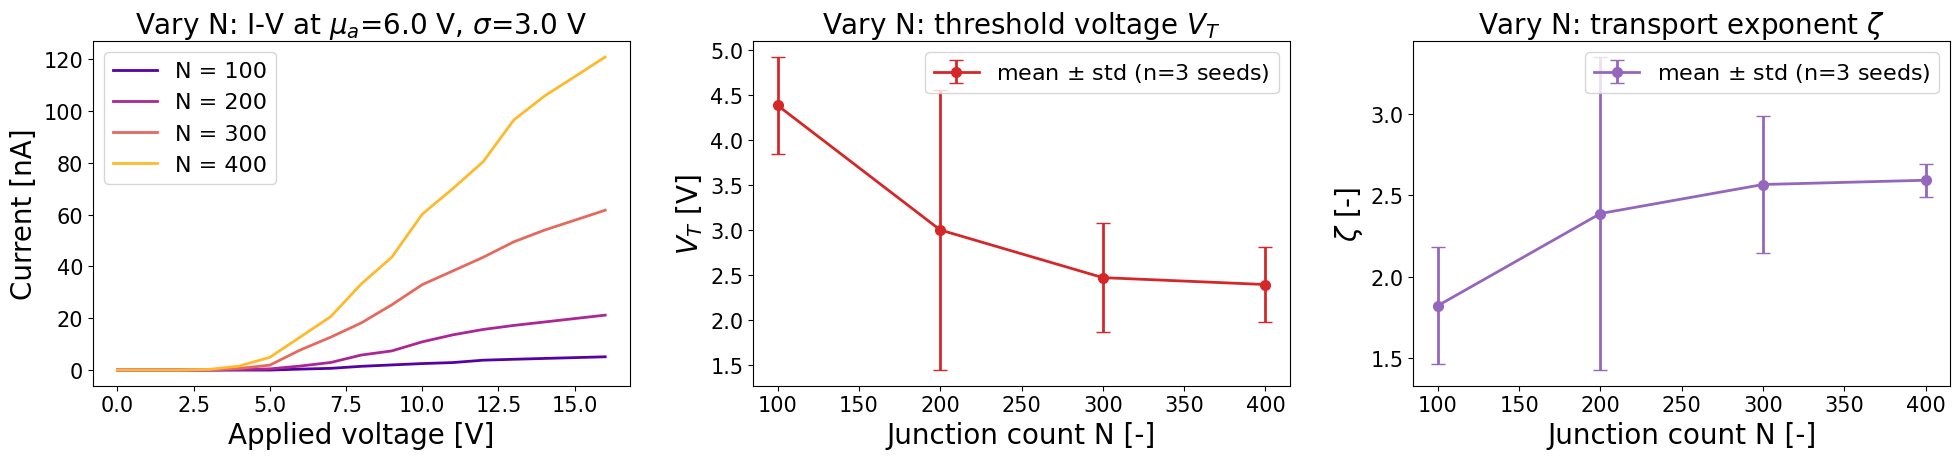

In [14]:
cfg_N = SweepConfig(
    L=1.0,
    mu_a=6.0, std_a=3.0,
    V_start=0.0, V_max=16.0, V_step=1.0,
    seeds=[42, 51, 27],
    max_workers=2,
    N_values=[100, 200, 300, 400],
    strict_N=True,   # ← add this
    fixed_mean_N=6.0,
    fixed_std_N=3.0,
)

vary_N_results = run_sweep_vary_N(cfg_N)
print(f"run_sweep_vary_N: {len(vary_N_results)} runs")

rep_N = {}
for r in vary_N_results:
    if r["N"] not in rep_N or r["seed"] < rep_N[r["N"]]["seed"]:
        rep_N[r["N"]] = r
reps_N = [rep_N[n] for n in sorted(rep_N)]

agg_N = aggregate_fit_table(vary_N_results, "N", "N")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_N = plt.cm.plasma(np.linspace(0.15, 0.85, len(reps_N)))

ax = axes[0]
for c, r in zip(colors_N, reps_N):
    ax.plot(r["voltages"], np.asarray(r["currents"]) * 1e9, lw=2, color=c,
            label=f"N = {r['N']}")
ax.set_xlabel("Applied voltage [V]")
ax.set_ylabel("Current [nA]")
ax.set_title(f"Vary N: I-V at $\\mu_a$={cfg_N.fixed_mean_N} V, $\\sigma$={cfg_N.fixed_std_N} V")
ax.legend()

ax = axes[1]
ax.errorbar(agg_N["N"], agg_N["VT_mean"], yerr=agg_N["VT_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:red",
            label=f"mean $\\pm$ std (n={len(cfg_N.seeds)} seeds)")
ax.set_xlabel("Junction count N [-]")
ax.set_ylabel("$V_T$ [V]")
ax.set_title("Vary N: threshold voltage $V_T$")
ax.legend()

ax = axes[2]
ax.errorbar(agg_N["N"], agg_N["zeta_mean"], yerr=agg_N["zeta_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:purple",
            label=f"mean $\\pm$ std (n={len(cfg_N.seeds)} seeds)")
ax.set_xlabel("Junction count N [-]")
ax.set_ylabel("$\\zeta$ [-]")
ax.set_title("Vary N: transport exponent $\\zeta$")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "vary_N.png", dpi=150)
plt.show()

### 6d. `run_sweep_vary_voids` — Vary void fraction fv

Network: 200 nodes, 1246 edges
Electrodes: 31 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1259 edges
Electrodes: 37 sources (x ≤ 0.150), 21 drains (x ≥ 0.850)
Network: 200 nodes, 1206 edges
Electrodes: 34 sources (x ≤ 0.150), 34 drains (x ≥ 0.850)
Network: 200 nodes, 1200 edges
Electrodes: 42 sources (x ≤ 0.150), 27 drains (x ≥ 0.850)
Network: 200 nodes, 1193 edges
Electrodes: 34 sources (x ≤ 0.150), 36 drains (x ≥ 0.850)
Network: 200 nodes, 1232 edges
Electrodes: 32 sources (x ≤ 0.150), 35 drains (x ≥ 0.850)
Network: 200 nodes, 1227 edges
Electrodes: 46 sources (x ≤ 0.150), 29 drains (x ≥ 0.850)
Network: 200 nodes, 1196 edges
Electrodes: 35 sources (x ≤ 0.150), 38 drains (x ≥ 0.850)
Network: 200 nodes, 1252 edges
Electrodes: 34 sources (x ≤ 0.150), 38 drains (x ≥ 0.850)
run_sweep_vary_voids: 9 runs


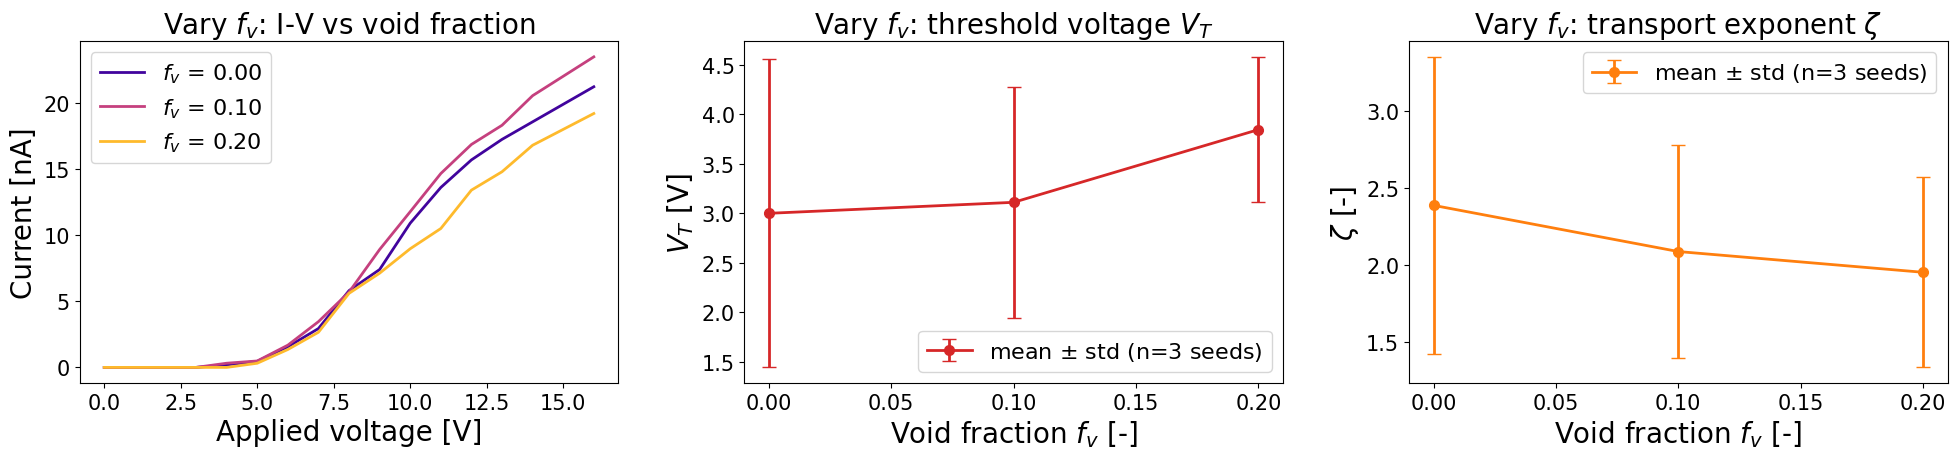

In [15]:
cfg_v = SweepConfig(
    L=1.0,
    V_start=0.0, V_max=16.0, V_step=1.0,
    seeds=[42, 51, 27],
    max_workers=2,
    void_fractions=[0.00, 0.10, 0.20],
    N_voids=200,
    mu_a_voids=6.0,
    std_a_voids=3.0,
    void_radius=0.08,
)

vary_voids_results = run_sweep_vary_voids(cfg_v)
print(f"run_sweep_vary_voids: {len(vary_voids_results)} runs")

rep_v = {}
for r in vary_voids_results:
    fv = r["void_fraction"]
    if fv not in rep_v or r["seed"] < rep_v[fv]["seed"]:
        rep_v[fv] = r
reps_v = [rep_v[fv] for fv in sorted(rep_v)]

agg_v = aggregate_fit_table(vary_voids_results, "void_fraction", "void_fraction")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_v = plt.cm.plasma(np.linspace(0.1, 0.85, len(reps_v)))

ax = axes[0]
for c, r in zip(colors_v, reps_v):
    ax.plot(r["voltages"], np.asarray(r["currents"]) * 1e9, lw=2, color=c,
            label=f"$f_v$ = {r['void_fraction']:.2f}")
ax.set_xlabel("Applied voltage [V]")
ax.set_ylabel("Current [nA]")
ax.set_title("Vary $f_v$: I-V vs void fraction")
ax.legend()

ax = axes[1]
ax.errorbar(agg_v["void_fraction"], agg_v["VT_mean"], yerr=agg_v["VT_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:red",
            label=f"mean $\\pm$ std (n={len(cfg_v.seeds)} seeds)")
ax.set_xlabel("Void fraction $f_v$ [-]")
ax.set_ylabel("$V_T$ [V]")
ax.set_title("Vary $f_v$: threshold voltage $V_T$")
ax.legend()

ax = axes[2]
ax.errorbar(agg_v["void_fraction"], agg_v["zeta_mean"], yerr=agg_v["zeta_std"],
            fmt="-o", ms=7, lw=2, capsize=5, color="tab:orange",
            label=f"mean $\\pm$ std (n={len(cfg_v.seeds)} seeds)")
ax.set_xlabel("Void fraction $f_v$ [-]")
ax.set_ylabel("$\\zeta$ [-]")
ax.set_title("Vary $f_v$: transport exponent $\\zeta$")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "vary_voids.png", dpi=150)
plt.show()

---
## 7. Void Network — Topology with Voids

When `fv > 0`, junctions are kept outside void circles and edges crossing a void are removed.

Network: 300 nodes, 2676 edges
Electrodes: 61 sources (x ≤ 0.150), 50 drains (x ≥ 0.850)
{'n_nodes': 300, 'n_edges': 2676, 'n_sources': 61, 'n_drains': 50, 'mean_degree': 17.84, 'density': 0.059665551839464884, 'is_connected': True, 'mu_a_actual': 5.964268048559629, 'std_a_actual': 2.819633507705121}
Voids placed: 7


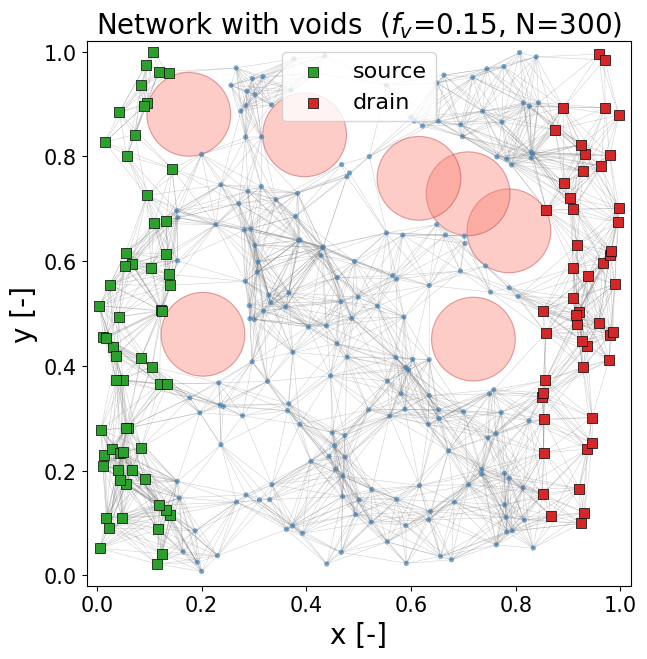

In [16]:
net_void = NanoparticleNetwork(
    L=1.0, N=300,
    fv=0.15,         # 15 % void area
    mu_a=6.0, std_a=3.0,
    void_radius=0.08,
).build(seed=42)

print(net_void.network_summary())
print(f"Voids placed: {len(net_void.voids)}")

pos_v = net_void.positions
fig, ax = plt.subplots(figsize=(7, 7))

# void circles
for v in net_void.voids:
    circ = plt.Circle(v["center"], v["radius"],
                      facecolor="salmon", edgecolor="firebrick",
                      alpha=0.4, lw=0.8, zorder=0)
    ax.add_patch(circ)

# edges
for i, j in net_void.G.edges():
    ax.plot([pos_v[i][0], pos_v[j][0]], [pos_v[i][1], pos_v[j][1]],
            lw=0.4, alpha=0.3, color="0.4")

# nodes
ids_v = list(net_void.G.nodes())
ax.scatter(pos_v[ids_v, 0], pos_v[ids_v, 1], s=14, c="steelblue",
           edgecolors="none", zorder=3, alpha=0.7)

if net_void.source_nodes:
    s = np.array(net_void.source_nodes)
    ax.scatter(pos_v[s, 0], pos_v[s, 1], marker="s", s=60, c="tab:green",
               edgecolors="k", lw=0.5, zorder=4, label="source")
if net_void.drain_nodes:
    d = np.array(net_void.drain_nodes)
    ax.scatter(pos_v[d, 0], pos_v[d, 1], marker="s", s=60, c="tab:red",
               edgecolors="k", lw=0.5, zorder=4, label="drain")

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal")
ax.legend()
ax.set_title(f"Network with voids  ($f_v$=0.15, N={net_void.n_junctions})")
ax.set_xlabel("x [-]"); ax.set_ylabel("y [-]")
plt.tight_layout()
plt.savefig(RESULTS / "void_topology.png", dpi=150)
plt.show()

---
## 8. Save / Load a Network

Networks can be pickled to disk and reloaded — the full graph, positions, and electrode assignments are preserved.

In [17]:
from nanonet.io import save_network, load_network

# Save
save_network(net, RESULTS / "network.pkl")
print(f"Saved to {RESULTS}/network.pkl")

# Reload and verify
net2 = load_network(RESULTS / "network.pkl")
print("Reloaded:", net2.network_summary())
print("Same graph?", net2.G.number_of_nodes() == net.G.number_of_nodes())

Saved to results/network.pkl
Reloaded: {'n_nodes': 300, 'n_edges': 2830, 'n_sources': 61, 'n_drains': 37, 'mean_degree': 18.866666666666667, 'density': 0.06309921962095875, 'is_connected': True, 'mu_a_actual': 5.964268048559629, 'std_a_actual': 2.819633507705121}
Same graph? True


---
## 9. Quick Reference

```python
# ── Build ─────────────────────────────────────────────────────────
net = NanoparticleNetwork(L, N, fv, mu_a, std_a).build(seed=42)
net.network_summary()

# ── I-V ───────────────────────────────────────────────────────────
iv = net.iv_curve(V_start, V_max, V_step)
# iv["voltages"], iv["currents"], iv["conductances"], iv["threshold_voltage"]

# ── Microscopic ───────────────────────────────────────────────────
mic = net.edge_currents(V_applied)
# mic["total_current"], mic["node_potentials"], mic["edge_currents"]
R   = net.overall_resistance(V_applied)

# ── Full sweep ────────────────────────────────────────────────────
result = sweep(net, V_start, V_max, V_step,
               effective_resistance=True, algebraic_connectivity=True)
write_iv_csv(result, "iv.csv")
write_csv(result, "sweep.csv")
write_edge_currents_csv(net, result, "edges.csv", voltages=[8.0, 12.0])

# ── Spectral (direct) ─────────────────────────────────────────────
activated = {n for n in net.G.nodes() if net.G.nodes[n]["Vth"] <= V}
R_eff             = effective_resistance(net, activated)
alg_conn, gap, _  = spectral_metrics(net, activated)

# ── Figures ───────────────────────────────────────────────────────
plot_iv_curve(result, "iv.png")
plot_evolution(result["rows"], result["fieldnames"], "title", "evo.png")
plot_snapshots(net, [4, 8, 12, 16], "snaps.png")
plot_spectral_evolution(result["rows"], result["fieldnames"], "title", "spectral.png")

# ── Parameter sweeps ──────────────────────────────────────────────
from nanonet.sweeps import (
    SweepConfig,
    run_sweep_vary_std,    # vary σ at fixed μ and N
    run_sweep_vary_mean,   # vary μ at each σ
    run_sweep_vary_N,      # vary N at fixed μ and σ
    run_sweep_vary_voids,  # vary fv at fixed N, μ, σ
    run_all_cases,         # run all four sweeps
)

cfg = SweepConfig(
    N=500, mu_a=6.0, std_a=3.0,
    sigma_values=[1.0, 3.0, 5.0, 7.0], fixed_mean=8.0,
    N_values=[200, 400, 600], fixed_mean_N=6.0, fixed_std_N=3.0,
    void_fractions=[0.0, 0.1, 0.2], N_voids=500,
    seeds=[42, 51],
)
results = run_sweep_vary_std(cfg)
fit_df  = make_fit_table(results, "vary_std")
agg_df  = aggregate_fit_table(results, "sigma_va_target", "sigma_V")

# ── I/O ───────────────────────────────────────────────────────────
save_network(net, "net.pkl")
net = load_network("net.pkl")
cfg = load_yaml_config("optimized_config.yaml")   # from nanonet.io
```